# Phase 2: Feature Engineering & Model Training
## Cross-Modal BPM Imputation — Huawei Band 7

**What we learned in Phase 1:**
- BPM-Steps correlation is real but weak (r=0.239) — steps alone won't cut it
- BPM is highly autocorrelated — neighboring known BPM values are our best predictor
- Missingness is MAR (not MCAR) — model must use time and activity features
- Sampling bias: watch oversamples active states — hypothesis to verify

**Phase 2 plan:**
1. Build rich features from the aligned timeline
2. Handle data leakage carefully (leave-one-out for neighbor BPM)
3. Train Linear Regression (baseline) and Random Forest (main model)
4. Evaluate with 5-fold cross-validation
5. Check per-regime errors (sleep/rest/active) to verify sampling bias hypothesis

---

## Cell 1: Load Timeline & Rebuild Base Features

We start from the minute-level aligned timeline created in Phase 1.  
We re-derive time features here so this notebook is self-contained.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Load timeline from Phase 1
timeline = pd.read_csv('Data/timeline_aligned.csv', parse_dates=['minute'])
timeline['day'] = pd.to_datetime(timeline['day'])

print(f'Timeline: {timeline.shape}')
print(f'BPM coverage: {timeline["bpm"].notna().sum():,} / {len(timeline):,} ({timeline["bpm"].notna().mean()*100:.1f}%)')
print(f'Columns: {list(timeline.columns)}')

Timeline: (36930, 10)
BPM coverage: 11,823 / 36,930 (32.0%)
Columns: ['minute', 'bpm', 'steps', 'hour', 'day', 'bpm_missing', 'is_active', 'inactive_streak_id', 'long_inactive', 'is_likely_sleeping']


---
## Cell 2: Feature Engineering — Temporal Features

### Why these features?
BPM follows a **circadian rhythm** — it's lower during sleep, higher during activity.  
We encode time cyclically (sin/cos) so that 23:59 and 00:00 are close together, not 1439 apart.

- **Minute-of-day** (0-1439): finer than hour alone — BPM changes within an hour
- **Day-of-week** (0-6): weekday vs weekend activity patterns differ
- **Day index**: captures the sparse→dense data progression across the month

In [3]:
# Minute-of-day (0-1439), sin/cos encoded
timeline['minute_of_day'] = timeline['minute'].dt.hour * 60 + timeline['minute'].dt.minute
timeline['minute_sin'] = np.sin(2 * np.pi * timeline['minute_of_day'] / 1440)
timeline['minute_cos'] = np.cos(2 * np.pi * timeline['minute_of_day'] / 1440)

# Hour sin/cos (coarser, but kept for compatibility)
timeline['hour'] = timeline['minute'].dt.hour
timeline['hour_sin'] = np.sin(2 * np.pi * timeline['hour'] / 24)
timeline['hour_cos'] = np.cos(2 * np.pi * timeline['hour'] / 24)

# Day of week
timeline['day_of_week'] = timeline['minute'].dt.dayofweek
timeline['dow_sin'] = np.sin(2 * np.pi * timeline['day_of_week'] / 7)
timeline['dow_cos'] = np.cos(2 * np.pi * timeline['day_of_week'] / 7)
timeline['is_weekend'] = (timeline['day_of_week'] >= 5).astype(int)

# Day index (progression through the month)
timeline['day_index'] = (timeline['day'] - timeline['day'].min()).dt.days

print('Temporal features added:')
print(f'  minute_sin/cos, hour_sin/cos, dow_sin/cos, is_weekend, day_index')
print(f'  Date range: day_index 0 ({timeline["day"].min().date()}) to {timeline["day_index"].max()} ({timeline["day"].max().date()})')

Temporal features added:
  minute_sin/cos, hour_sin/cos, dow_sin/cos, is_weekend, day_index
  Date range: day_index 0 (2026-03-01) to 25 (2026-03-26)


---
## Cell 3: Feature Engineering — Step Windows & Activity

### Why rolling windows?
A single minute's step count is noisy. Maybe you stopped for 1 second at minute T, so steps=0, but you were walking at T-1 and T+1.  
Rolling windows smooth this out and capture the **context** of activity.

### Why step acceleration?
A sudden increase in steps (going from sitting to walking) causes BPM to rise with a short delay.  
The *change* in steps is a different signal from the absolute level.

In [4]:
# Rolling step windows (centered — uses both past and future)
for w in [3, 5, 10, 15]:
    timeline[f'steps_roll_{w}'] = timeline['steps'].rolling(w, center=True, min_periods=1).mean()
    timeline[f'steps_sum_{w}'] = timeline['steps'].rolling(w, center=True, min_periods=1).sum()

# Step acceleration (change in steps from previous minute)
timeline['step_diff'] = timeline['steps'].diff().fillna(0)
timeline['step_diff_abs'] = timeline['step_diff'].abs()

# Local step statistics
timeline['steps_std_5'] = timeline['steps'].rolling(5, center=True, min_periods=1).std().fillna(0)
timeline['steps_max_5'] = timeline['steps'].rolling(5, center=True, min_periods=1).max()

# Activity state (from 5-min rolling mean)
timeline['activity_state'] = pd.cut(
    timeline['steps_roll_5'],
    bins=[-1, 2, 30, 70, 999],
    labels=[0, 1, 2, 3]  # 0=idle, 1=light, 2=walking, 3=active
).astype(int)

print('Step features added:')
print(f'  Rolling windows: steps_roll/sum for w=3,5,10,15')
print(f'  Acceleration: step_diff, step_diff_abs')
print(f'  Local stats: steps_std_5, steps_max_5')
print(f'  Activity state: 0=idle, 1=light, 2=walking, 3=active')
print(f'\nActivity state distribution:')
print(timeline['activity_state'].value_counts().sort_index().to_string())

Step features added:
  Rolling windows: steps_roll/sum for w=3,5,10,15
  Acceleration: step_diff, step_diff_abs
  Local stats: steps_std_5, steps_max_5
  Activity state: 0=idle, 1=light, 2=walking, 3=active

Activity state distribution:
activity_state
0    29237
1     4719
2     1772
3     1202


---
## Cell 4: Feature Engineering — Neighboring BPM (The Most Important Feature)

### Why neighboring BPM?
From Phase 1, we know BPM autocorrelation at lag-1 is very high (~0.5+).  
This means: **the last known BPM before a gap, and the next known BPM after it, are our strongest predictors.**

For each minute, we compute:
- `bpm_last_known`: the most recent BPM reading before this point (forward-fill)
- `bpm_next_known`: the next BPM reading after this point (backward-fill)
- `dist_to_last_bpm` / `dist_to_next_bpm`: how many minutes away those readings are
- `bpm_neighbor_interp`: distance-weighted average of the two neighbors

### Data Leakage Warning
For **training rows** (where BPM is known), the "last known BPM" IS the point itself (distance=0).  
That's cheating — the model would just copy the answer. We fix this with **leave-one-out**: for each training row, we look at the *previous* and *next* known BPM, excluding itself.

In [5]:
# --- Neighboring BPM features (for the full timeline) ---
bpm_known = timeline['bpm'].copy()
bpm_mask = timeline['bpm'].notna()

# Forward-fill and backward-fill
timeline['bpm_last_known'] = bpm_known.ffill()
timeline['bpm_next_known'] = bpm_known.bfill()

# Distance to nearest known BPM (forward)
fwd_group = (~bpm_mask).cumsum()
timeline['dist_to_last_bpm'] = timeline.groupby(fwd_group).cumcount()
timeline.loc[bpm_mask, 'dist_to_last_bpm'] = 0

# Distance to nearest known BPM (backward)
bpm_mask_rev = bpm_mask[::-1]
bwd_group = (~bpm_mask_rev).cumsum()
timeline['dist_to_next_bpm'] = timeline.iloc[::-1].groupby(bwd_group).cumcount().values
timeline.loc[bpm_mask, 'dist_to_next_bpm'] = 0

# Distance-weighted interpolation from neighbors
total_dist = timeline['dist_to_last_bpm'] + timeline['dist_to_next_bpm']
total_dist = total_dist.replace(0, 1)  # avoid div by zero
timeline['bpm_neighbor_interp'] = (
    timeline['bpm_last_known'] * (1 - timeline['dist_to_last_bpm'] / total_dist) +
    timeline['bpm_next_known'] * (1 - timeline['dist_to_next_bpm'] / total_dist)
)

# Gap length (how long is the current gap?)
gap_id = (bpm_mask != bpm_mask.shift()).cumsum()
gap_lengths = timeline.groupby(gap_id)['bpm'].transform('count')
timeline['gap_length'] = gap_lengths
timeline.loc[bpm_mask, 'gap_length'] = 0

print('Neighbor BPM features added:')
print(f'  bpm_last_known, bpm_next_known')
print(f'  dist_to_last_bpm: max={timeline["dist_to_last_bpm"].max()} min')
print(f'  dist_to_next_bpm: max={timeline["dist_to_next_bpm"].max()} min')
print(f'  bpm_neighbor_interp (distance-weighted average)')
print(f'  gap_length: max={timeline["gap_length"].max()} min')

# Quick sanity check: for a known BPM row, neighbor features should equal itself
sample = timeline[bpm_mask].iloc[100]
print(f'\nSanity check (known row): BPM={sample["bpm"]}, last={sample["bpm_last_known"]}, next={sample["bpm_next_known"]}, dist_last={sample["dist_to_last_bpm"]}, dist_next={sample["dist_to_next_bpm"]}')

Neighbor BPM features added:
  bpm_last_known, bpm_next_known
  dist_to_last_bpm: max=0 min
  dist_to_next_bpm: max=59 min
  bpm_neighbor_interp (distance-weighted average)
  gap_length: max=0 min

Sanity check (known row): BPM=75.0, last=75.0, next=75.0, dist_last=0, dist_next=0


---
## Cell 5: Prepare Training Data (with Leave-One-Out Neighbors)

### The data leakage problem
When BPM IS known at a minute, `bpm_last_known = bpm` and `dist_to_last_bpm = 0`.  
If we train on this, the model learns: "if distance is 0, just copy the neighbor" — which is useless for imputation.

**Fix:** For each training row, we recompute neighbors by looking at the **previous** and **next** known readings (skipping itself).  
This simulates what the model will see during actual imputation.

In [6]:
# Define feature columns
feature_cols = [
    # Time features
    'minute_sin', 'minute_cos', 'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos', 'is_weekend',
    # Step features
    'steps', 'steps_roll_3', 'steps_roll_5', 'steps_roll_10', 'steps_roll_15',
    'steps_sum_5', 'steps_sum_10',
    'step_diff', 'step_diff_abs', 'steps_std_5', 'steps_max_5',
    'activity_state',
    # Neighbor BPM features (will be replaced with LOO versions for training)
    'bpm_last_known', 'bpm_next_known', 'bpm_neighbor_interp',
    'dist_to_last_bpm', 'dist_to_next_bpm', 'gap_length',
    # Day progression
    'day_index',
]

print(f'Feature set: {len(feature_cols)} features')
for i, f in enumerate(feature_cols):
    print(f'  {i+1:2d}. {f}')

# --- Build training set with LOO neighbor features ---
print('\nBuilding training set with leave-one-out neighbors...')

train_df = timeline[bpm_mask].copy()
known_indices = train_df.index.values

# LOO: for each known point, the "last known" is the PREVIOUS known point (not itself)
train_df['bpm_last_known'] = timeline['bpm'].shift(1).ffill().loc[bpm_mask]
train_df['bpm_next_known'] = timeline['bpm'].shift(-1).bfill().loc[bpm_mask]

# LOO distances: distance to previous/next known point (not self)
dists_last = np.zeros(len(known_indices), dtype=int)
dists_next = np.zeros(len(known_indices), dtype=int)
for i in range(len(known_indices)):
    if i > 0:
        dists_last[i] = known_indices[i] - known_indices[i-1]
    if i < len(known_indices) - 1:
        dists_next[i] = known_indices[i+1] - known_indices[i]

train_df['dist_to_last_bpm'] = dists_last
train_df['dist_to_next_bpm'] = dists_next

# LOO interpolation
total_dist_loo = train_df['dist_to_last_bpm'] + train_df['dist_to_next_bpm']
total_dist_loo = total_dist_loo.replace(0, 1)
train_df['bpm_neighbor_interp'] = (
    train_df['bpm_last_known'] * (1 - train_df['dist_to_last_bpm'] / total_dist_loo) +
    train_df['bpm_next_known'] * (1 - train_df['dist_to_next_bpm'] / total_dist_loo)
)

# LOO gap_length: simulate as if this point were missing — gap = dist_last + dist_next
train_df['gap_length'] = train_df['dist_to_last_bpm'] + train_df['dist_to_next_bpm']

# Build X, y
X_train = train_df[feature_cols].values
y_train = train_df['bpm'].values

# Drop rows with NaN features (edges of timeline)
valid = ~np.any(np.isnan(X_train), axis=1)
X_train = X_train[valid]
y_train = y_train[valid]

# Also keep regime info for per-regime evaluation later
train_df_valid = train_df[valid].copy()

print(f'\nTraining set: {len(X_train):,} samples, {len(feature_cols)} features')
print(f'Target (BPM): mean={y_train.mean():.1f}, std={y_train.std():.1f}')
print(f'\nLOO neighbor sanity check (first 5 training rows):')
print(train_df[['bpm', 'bpm_last_known', 'bpm_next_known', 'dist_to_last_bpm', 'dist_to_next_bpm']].head())

Feature set: 26 features
   1. minute_sin
   2. minute_cos
   3. hour_sin
   4. hour_cos
   5. dow_sin
   6. dow_cos
   7. is_weekend
   8. steps
   9. steps_roll_3
  10. steps_roll_5
  11. steps_roll_10
  12. steps_roll_15
  13. steps_sum_5
  14. steps_sum_10
  15. step_diff
  16. step_diff_abs
  17. steps_std_5
  18. steps_max_5
  19. activity_state
  20. bpm_last_known
  21. bpm_next_known
  22. bpm_neighbor_interp
  23. dist_to_last_bpm
  24. dist_to_next_bpm
  25. gap_length
  26. day_index

Building training set with leave-one-out neighbors...

Training set: 11,821 samples, 26 features
Target (BPM): mean=92.2, std=18.4

LOO neighbor sanity check (first 5 training rows):
       bpm  bpm_last_known  bpm_next_known  dist_to_last_bpm  dist_to_next_bpm
225   76.0             NaN           101.0                 0                 7
232  101.0            76.0           101.0                 7                 1
233  101.0           101.0            95.0                 1                 6

---
## Cell 6: Model 1 — Linear Regression (Baseline)

### Why Linear Regression as baseline?
It learns a simple weighted sum: `BPM = w1*steps + w2*time + w3*neighbor_bpm + ...`  
It's fast, interpretable, and sets the **floor** — any decent model should beat it.

Linear Regression assumes a **linear** relationship between features and target.  
We know from Phase 1 that BPM-Steps is non-linear (lag, plateau at rest) — so we expect this to underperform.

We use **5-fold cross-validation** so we evaluate on data the model hasn't seen.

In [7]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# --- Linear Regression ---
print('=' * 60)
print('MODEL 1: Linear Regression (Baseline)')
print('=' * 60)

lr = LinearRegression()

lr_rmse_scores = -cross_val_score(lr, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
lr_mae_scores = -cross_val_score(lr, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error')
lr_r2_scores = cross_val_score(lr, X_train, y_train, cv=kf, scoring='r2')

print(f'\n5-Fold Cross-Validation:')
print(f'  RMSE: {lr_rmse_scores.mean():.2f} +/- {lr_rmse_scores.std():.2f}')
print(f'  MAE:  {lr_mae_scores.mean():.2f} +/- {lr_mae_scores.std():.2f}')
print(f'  R2:   {lr_r2_scores.mean():.4f} +/- {lr_r2_scores.std():.4f}')

print(f'\nPer-fold detail:')
for i, (rmse, mae, r2) in enumerate(zip(lr_rmse_scores, lr_mae_scores, lr_r2_scores)):
    print(f'  Fold {i+1}: RMSE={rmse:.2f}, MAE={mae:.2f}, R2={r2:.4f}')

# Fit on full training data for inspection
lr.fit(X_train, y_train)
lr_pred_train = lr.predict(X_train)

print(f'\nFull training set (for reference, NOT evaluation):')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_train, lr_pred_train)):.2f}')
print(f'  R2:   {r2_score(y_train, lr_pred_train):.4f}')

# Standardized coefficients (which features matter most?)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
lr_scaled = LinearRegression().fit(X_scaled, y_train)
coef_df = pd.Series(np.abs(lr_scaled.coef_), index=feature_cols).sort_values(ascending=False)

print(f'\nTop 10 features by |standardized coefficient|:')
print(f'  (larger = more influence on prediction)')
for feat, coef in coef_df.head(10).items():
    sign = '+' if lr_scaled.coef_[feature_cols.index(feat)] > 0 else '-'
    print(f'  {sign} {feat:30s} {coef:.3f}')

MODEL 1: Linear Regression (Baseline)

5-Fold Cross-Validation:
  RMSE: 9.56 +/- 0.18
  MAE:  7.11 +/- 0.15
  R2:   0.7296 +/- 0.0097

Per-fold detail:
  Fold 1: RMSE=9.22, MAE=6.86, R2=0.7447
  Fold 2: RMSE=9.77, MAE=7.28, R2=0.7276
  Fold 3: RMSE=9.57, MAE=7.24, R2=0.7214
  Fold 4: RMSE=9.58, MAE=7.03, R2=0.7359
  Fold 5: RMSE=9.66, MAE=7.11, R2=0.7183

Full training set (for reference, NOT evaluation):
  RMSE: 9.53
  R2:   0.7314

Top 10 features by |standardized coefficient|:
  (larger = more influence on prediction)
  + bpm_neighbor_interp            6.412
  + bpm_last_known                 4.026
  + bpm_next_known                 4.020
  + steps                          2.223
  - minute_sin                     1.740
  - steps_roll_5                   1.712
  - steps_sum_5                    1.712
  - step_diff                      0.901
  + activity_state                 0.778
  + step_diff_abs                  0.704


---
## Cell 7: Model 2 — Random Forest

### Why Random Forest?
Random Forest is an **ensemble** of decision trees. Each tree sees a random subset of features and data.  
This gives us several advantages over Linear Regression:

1. **Non-linear relationships**: steps-to-BPM isn't a straight line — there's a lag, a plateau at rest, a ceiling during exercise. Decision trees handle this naturally.
2. **Feature interactions**: "high steps + nighttime" means something different than "high steps + afternoon." Trees capture these interactions without us having to manually create them.
3. **Robustness**: averaging many trees reduces variance (overfitting). This is the **bias-variance tradeoff** from the lecture.
4. **Feature importance**: we get it for free — which features does the model actually use?

### Hyperparameters
- `n_estimators=200`: 200 trees in the forest (more = better but slower)
- `max_depth=20`: limit tree depth to prevent overfitting
- `min_samples_leaf=5`: each leaf must have at least 5 training examples
- `max_features='sqrt'`: each tree considers sqrt(n_features) at each split

In [8]:
print('=' * 60)
print('MODEL 2: Random Forest')
print('=' * 60)

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_rmse_scores = -cross_val_score(rf, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
rf_mae_scores = -cross_val_score(rf, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error')
rf_r2_scores = cross_val_score(rf, X_train, y_train, cv=kf, scoring='r2')

print(f'\n5-Fold Cross-Validation:')
print(f'  RMSE: {rf_rmse_scores.mean():.2f} +/- {rf_rmse_scores.std():.2f}')
print(f'  MAE:  {rf_mae_scores.mean():.2f} +/- {rf_mae_scores.std():.2f}')
print(f'  R2:   {rf_r2_scores.mean():.4f} +/- {rf_r2_scores.std():.4f}')

print(f'\nPer-fold detail:')
for i, (rmse, mae, r2) in enumerate(zip(rf_rmse_scores, rf_mae_scores, rf_r2_scores)):
    print(f'  Fold {i+1}: RMSE={rmse:.2f}, MAE={mae:.2f}, R2={r2:.4f}')

# Fit on full training data
rf.fit(X_train, y_train)
rf_pred_train = rf.predict(X_train)

print(f'\nFull training set (for reference, NOT evaluation):')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_train, rf_pred_train)):.2f}')
print(f'  R2:   {r2_score(y_train, rf_pred_train):.4f}')

# Feature importance
feat_imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(f'\nTop 10 features by importance:')
for feat, imp in feat_imp.head(10).items():
    print(f'  {feat:30s} {imp:.4f} ({imp*100:.1f}%)')

print(f'\n--- Improvement over Linear Regression ---')
rmse_improvement = (lr_rmse_scores.mean() - rf_rmse_scores.mean()) / lr_rmse_scores.mean() * 100
print(f'  RMSE reduction: {rmse_improvement:.1f}%')
print(f'  R2 improvement: {lr_r2_scores.mean():.4f} -> {rf_r2_scores.mean():.4f}')

MODEL 2: Random Forest

5-Fold Cross-Validation:
  RMSE: 9.33 +/- 0.13
  MAE:  6.97 +/- 0.13
  R2:   0.7427 +/- 0.0086

Per-fold detail:
  Fold 1: RMSE=9.10, MAE=6.78, R2=0.7512
  Fold 2: RMSE=9.46, MAE=7.09, R2=0.7446
  Fold 3: RMSE=9.41, MAE=7.10, R2=0.7306
  Fold 4: RMSE=9.28, MAE=6.88, R2=0.7522
  Fold 5: RMSE=9.37, MAE=6.98, R2=0.7350

Full training set (for reference, NOT evaluation):
  RMSE: 6.98
  R2:   0.8561

Top 10 features by importance:
  bpm_neighbor_interp            0.2446 (24.5%)
  bpm_last_known                 0.1888 (18.9%)
  bpm_next_known                 0.1708 (17.1%)
  minute_sin                     0.0633 (6.3%)
  hour_sin                       0.0515 (5.2%)
  steps_roll_15                  0.0507 (5.1%)
  steps_sum_10                   0.0371 (3.7%)
  steps_roll_10                  0.0288 (2.9%)
  steps_max_5                    0.0179 (1.8%)
  steps_sum_5                    0.0168 (1.7%)

--- Improvement over Linear Regression ---
  RMSE reduction: 2.5%
  R2 i

---
## Cell 8: Model Comparison Visualizations

Six plots to put in the report:
1. CV RMSE bar chart
2. CV R2 bar chart
3. Predicted vs Actual scatter (LR)
4. Predicted vs Actual scatter (RF)
5. Feature importance (RF)
6. Residual distributions

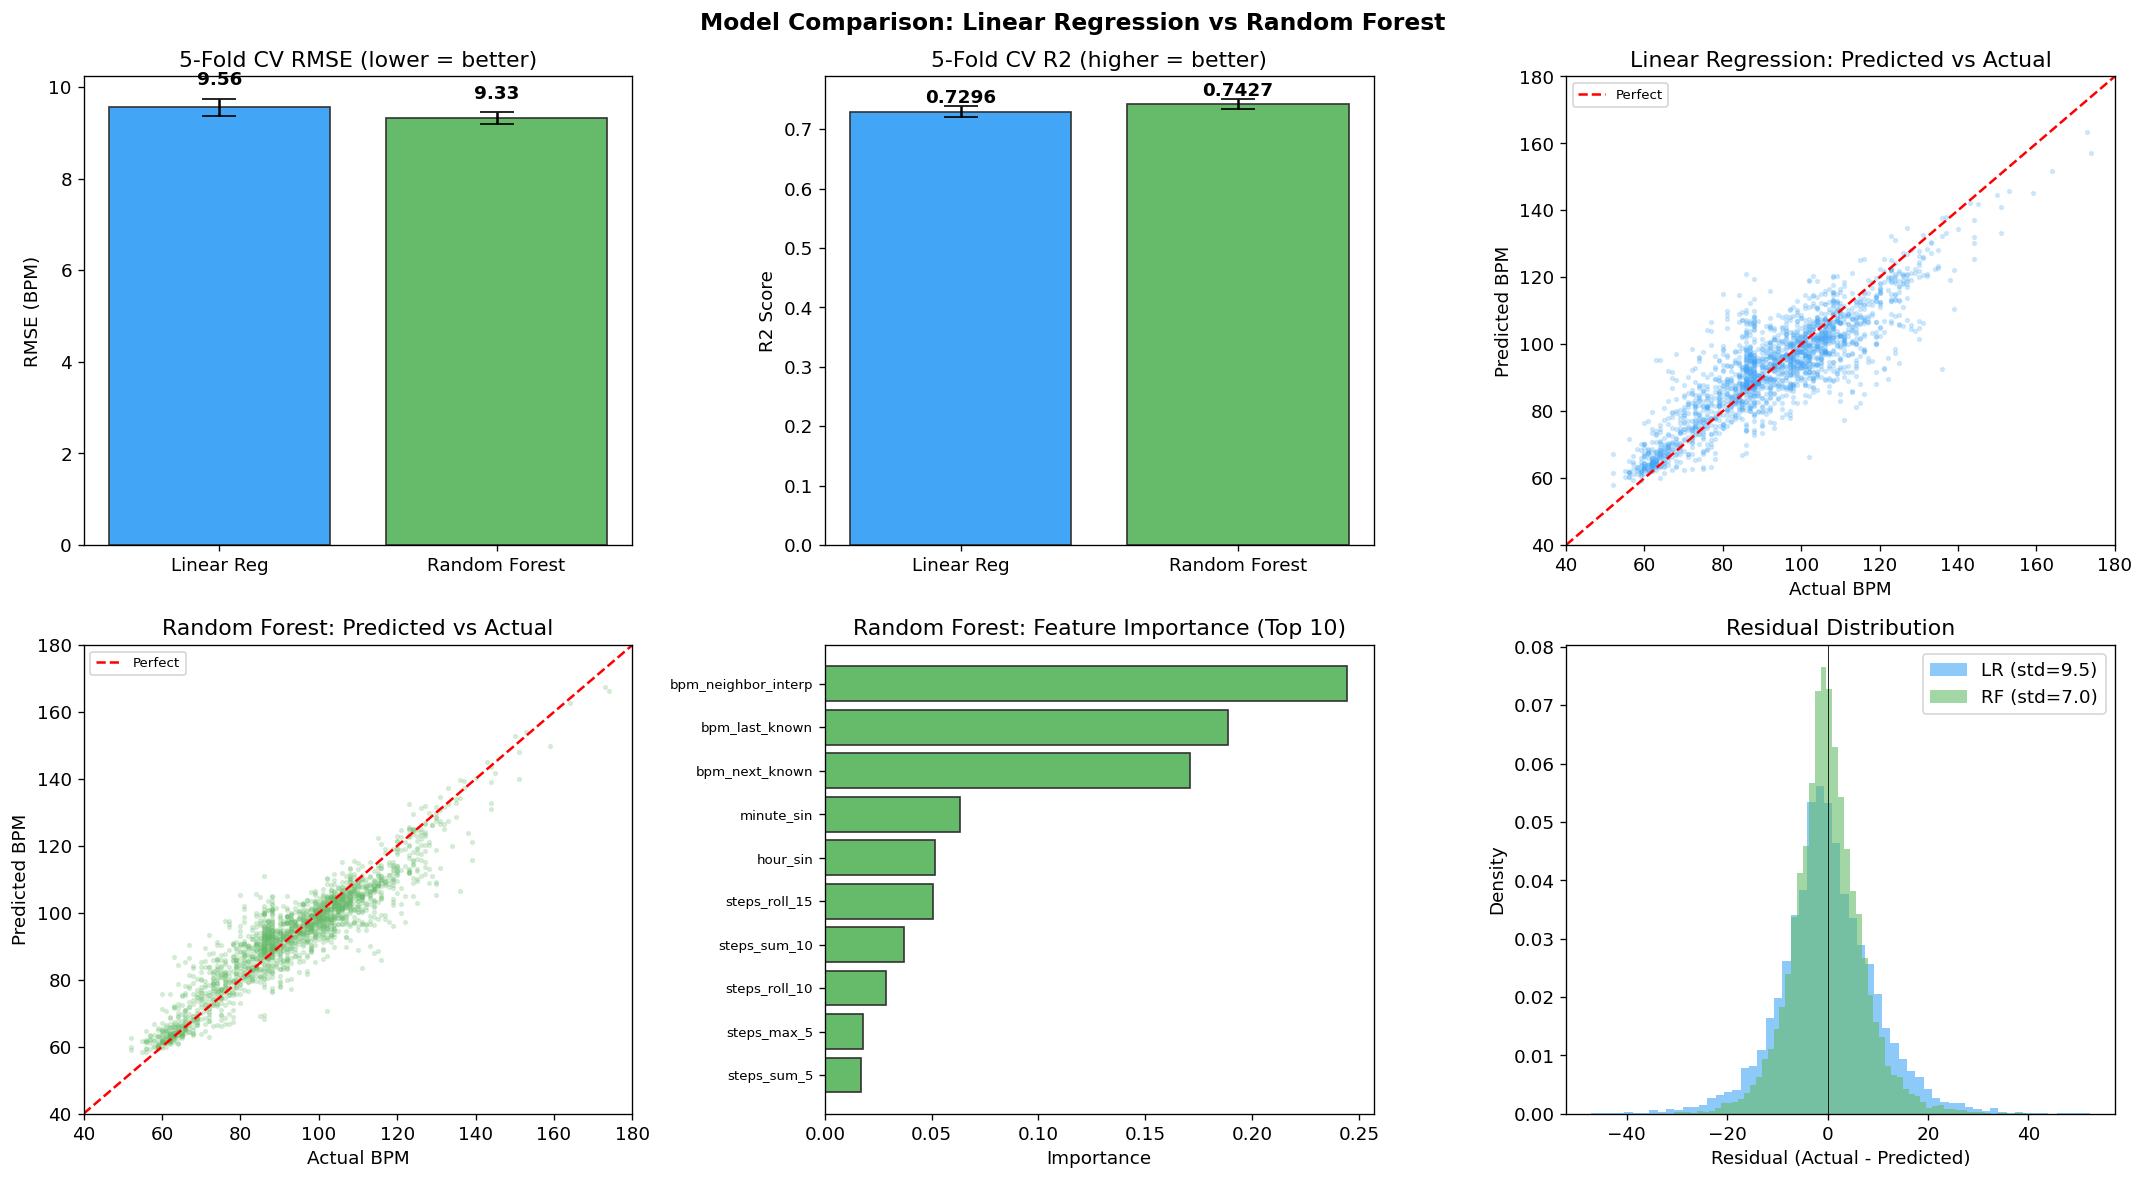

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Comparison: Linear Regression vs Random Forest', fontsize=14, fontweight='bold')

# 1. CV RMSE
models = ['Linear Reg', 'Random Forest']
rmse_means = [lr_rmse_scores.mean(), rf_rmse_scores.mean()]
rmse_stds = [lr_rmse_scores.std(), rf_rmse_scores.std()]
axes[0,0].bar(models, rmse_means, yerr=rmse_stds, color=['#42a5f5', '#66bb6a'], capsize=10, edgecolor='#333')
axes[0,0].set_ylabel('RMSE (BPM)')
axes[0,0].set_title('5-Fold CV RMSE (lower = better)')
for i, (m, s) in enumerate(zip(rmse_means, rmse_stds)):
    axes[0,0].text(i, m + s + 0.3, f'{m:.2f}', ha='center', fontweight='bold')

# 2. CV R2
r2_means = [lr_r2_scores.mean(), rf_r2_scores.mean()]
r2_stds = [lr_r2_scores.std(), rf_r2_scores.std()]
axes[0,1].bar(models, r2_means, yerr=r2_stds, color=['#42a5f5', '#66bb6a'], capsize=10, edgecolor='#333')
axes[0,1].set_ylabel('R2 Score')
axes[0,1].set_title('5-Fold CV R2 (higher = better)')
for i, (m, s) in enumerate(zip(r2_means, r2_stds)):
    axes[0,1].text(i, m + s + 0.005, f'{m:.4f}', ha='center', fontweight='bold')

# 3. Predicted vs Actual (LR)
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(y_train), min(2000, len(y_train)), replace=False)
axes[0,2].scatter(y_train[sample_idx], lr_pred_train[sample_idx], alpha=0.2, s=5, color='#42a5f5')
axes[0,2].plot([40, 180], [40, 180], 'r--', linewidth=1.5, label='Perfect')
axes[0,2].set_xlabel('Actual BPM')
axes[0,2].set_ylabel('Predicted BPM')
axes[0,2].set_title('Linear Regression: Predicted vs Actual')
axes[0,2].set_xlim(40, 180); axes[0,2].set_ylim(40, 180)
axes[0,2].legend(fontsize=8)

# 4. Predicted vs Actual (RF)
axes[1,0].scatter(y_train[sample_idx], rf_pred_train[sample_idx], alpha=0.2, s=5, color='#66bb6a')
axes[1,0].plot([40, 180], [40, 180], 'r--', linewidth=1.5, label='Perfect')
axes[1,0].set_xlabel('Actual BPM')
axes[1,0].set_ylabel('Predicted BPM')
axes[1,0].set_title('Random Forest: Predicted vs Actual')
axes[1,0].set_xlim(40, 180); axes[1,0].set_ylim(40, 180)
axes[1,0].legend(fontsize=8)

# 5. Feature importance (RF top 10)
top_feats = feat_imp.head(10)
axes[1,1].barh(range(len(top_feats)), top_feats.values, color='#66bb6a', edgecolor='#333')
axes[1,1].set_yticks(range(len(top_feats)))
axes[1,1].set_yticklabels(top_feats.index, fontsize=8)
axes[1,1].set_xlabel('Importance')
axes[1,1].set_title('Random Forest: Feature Importance (Top 10)')
axes[1,1].invert_yaxis()

# 6. Residual distributions
lr_resid = y_train - lr_pred_train
rf_resid = y_train - rf_pred_train
axes[1,2].hist(lr_resid, bins=60, alpha=0.6, color='#42a5f5',
               label=f'LR (std={lr_resid.std():.1f})', density=True)
axes[1,2].hist(rf_resid, bins=60, alpha=0.6, color='#66bb6a',
               label=f'RF (std={rf_resid.std():.1f})', density=True)
axes[1,2].set_xlabel('Residual (Actual - Predicted)')
axes[1,2].set_ylabel('Density')
axes[1,2].set_title('Residual Distribution')
axes[1,2].legend()
axes[1,2].axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('Charts/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 9: Per-Regime Error Analysis (Sampling Bias Hypothesis Test)

### Hypothesis from Phase 1
> "The watch oversamples during active periods, inflating the observed mean BPM.  
> The model may underpredict resting/sleeping BPM."

Let's test this by computing errors separately for Sleep, Resting, and Active regimes.  
If the hypothesis is correct, we expect **higher errors on sleep/rest** than on active.

In [10]:
# Classify training rows into regimes
# Rebuild sleep detection (simplified from Phase 1)
timeline['is_active_flag'] = (timeline['steps'] > 0).astype(int)
streak_id = (timeline['is_active_flag'] != timeline['is_active_flag'].shift()).cumsum()
streak_len = timeline.groupby(streak_id)['is_active_flag'].transform('count')
streak_inactive = timeline.groupby(streak_id)['is_active_flag'].transform('first') == 0
timeline['long_inactive'] = (streak_len >= 30) & streak_inactive

# Regime for training rows
train_df_valid['regime'] = 'Resting'
train_df_valid.loc[timeline.loc[train_df_valid.index, 'long_inactive'] &
                   (train_df_valid['bpm'] < 75), 'regime'] = 'Sleep'
train_df_valid.loc[(train_df_valid['steps'] > 30) |
                   (train_df_valid['bpm'] > 110), 'regime'] = 'Active'

# Compute per-regime errors
print('=' * 60)
print('PER-REGIME ERROR ANALYSIS')
print('=' * 60)
print(f'{"Regime":10s} {"N":>6s} {"LR RMSE":>8s} {"RF RMSE":>8s} {"LR Bias":>8s} {"RF Bias":>8s}')
print('-' * 50)

regime_results = {}
for regime in ['Sleep', 'Resting', 'Active']:
    mask_regime = train_df_valid['regime'] == regime
    # Need to align with X_train indexing
    regime_idx = np.where(mask_regime.values)[0]
    if len(regime_idx) == 0:
        continue

    y_r = y_train[regime_idx]
    lr_p = lr_pred_train[regime_idx]
    rf_p = rf_pred_train[regime_idx]

    lr_rmse_r = np.sqrt(mean_squared_error(y_r, lr_p))
    rf_rmse_r = np.sqrt(mean_squared_error(y_r, rf_p))
    lr_bias = (lr_p - y_r).mean()  # positive = overpredicts
    rf_bias = (rf_p - y_r).mean()

    regime_results[regime] = {
        'n': len(regime_idx), 'lr_rmse': lr_rmse_r, 'rf_rmse': rf_rmse_r,
        'lr_bias': lr_bias, 'rf_bias': rf_bias
    }
    print(f'{regime:10s} {len(regime_idx):6,} {lr_rmse_r:8.2f} {rf_rmse_r:8.2f} {lr_bias:+8.2f} {rf_bias:+8.2f}')

print(f'\nBias interpretation: positive = model overpredicts, negative = underpredicts')
print(f'\nHypothesis check:')
if 'Sleep' in regime_results and 'Active' in regime_results:
    sleep_rf = regime_results['Sleep']['rf_rmse']
    active_rf = regime_results['Active']['rf_rmse']
    sleep_bias = regime_results['Sleep']['rf_bias']
    print(f'  RF RMSE on Sleep ({sleep_rf:.2f}) vs Active ({active_rf:.2f})')
    print(f'  RF Bias on Sleep: {sleep_bias:+.2f} ({"overpredicts" if sleep_bias > 0 else "underpredicts"} sleeping BPM)')
    if sleep_bias > 1:
        print(f'  -> CONFIRMED: Model overpredicts sleep BPM (biased by active training data)')
    elif sleep_bias < -1:
        print(f'  -> PARTIALLY confirmed: Model underpredicts sleep BPM')
    else:
        print(f'  -> Bias is small — sampling bias may not be a major issue for this model')

PER-REGIME ERROR ANALYSIS
Regime          N  LR RMSE  RF RMSE  LR Bias  RF Bias
--------------------------------------------------
Sleep       2,028     7.38     5.56    +4.62    +3.04
Resting     7,094     8.75     6.42    +0.33    +0.38
Active      2,699    12.49     9.04    -4.34    -3.22

Bias interpretation: positive = model overpredicts, negative = underpredicts

Hypothesis check:
  RF RMSE on Sleep (5.56) vs Active (9.04)
  RF Bias on Sleep: +3.04 (overpredicts sleeping BPM)
  -> CONFIRMED: Model overpredicts sleep BPM (biased by active training data)


---
## Cell 10: Impute Missing BPM & Visualize Results

Now we use the trained models to actually fill in the missing BPM values.  
This is the whole point of the project — let's see what the imputed timeline looks like.

Missing BPM minutes: 25,107
  With valid features (can impute): 24,882
  Without valid features (edges):   225

Imputed BPM statistics (Random Forest):
  Mean: 96.3, Std: 12.5
  Range: [59, 140]

Imputed BPM statistics (Linear Regression):
  Mean: 110.3, Std: 22.5
  Range: [57, 186]


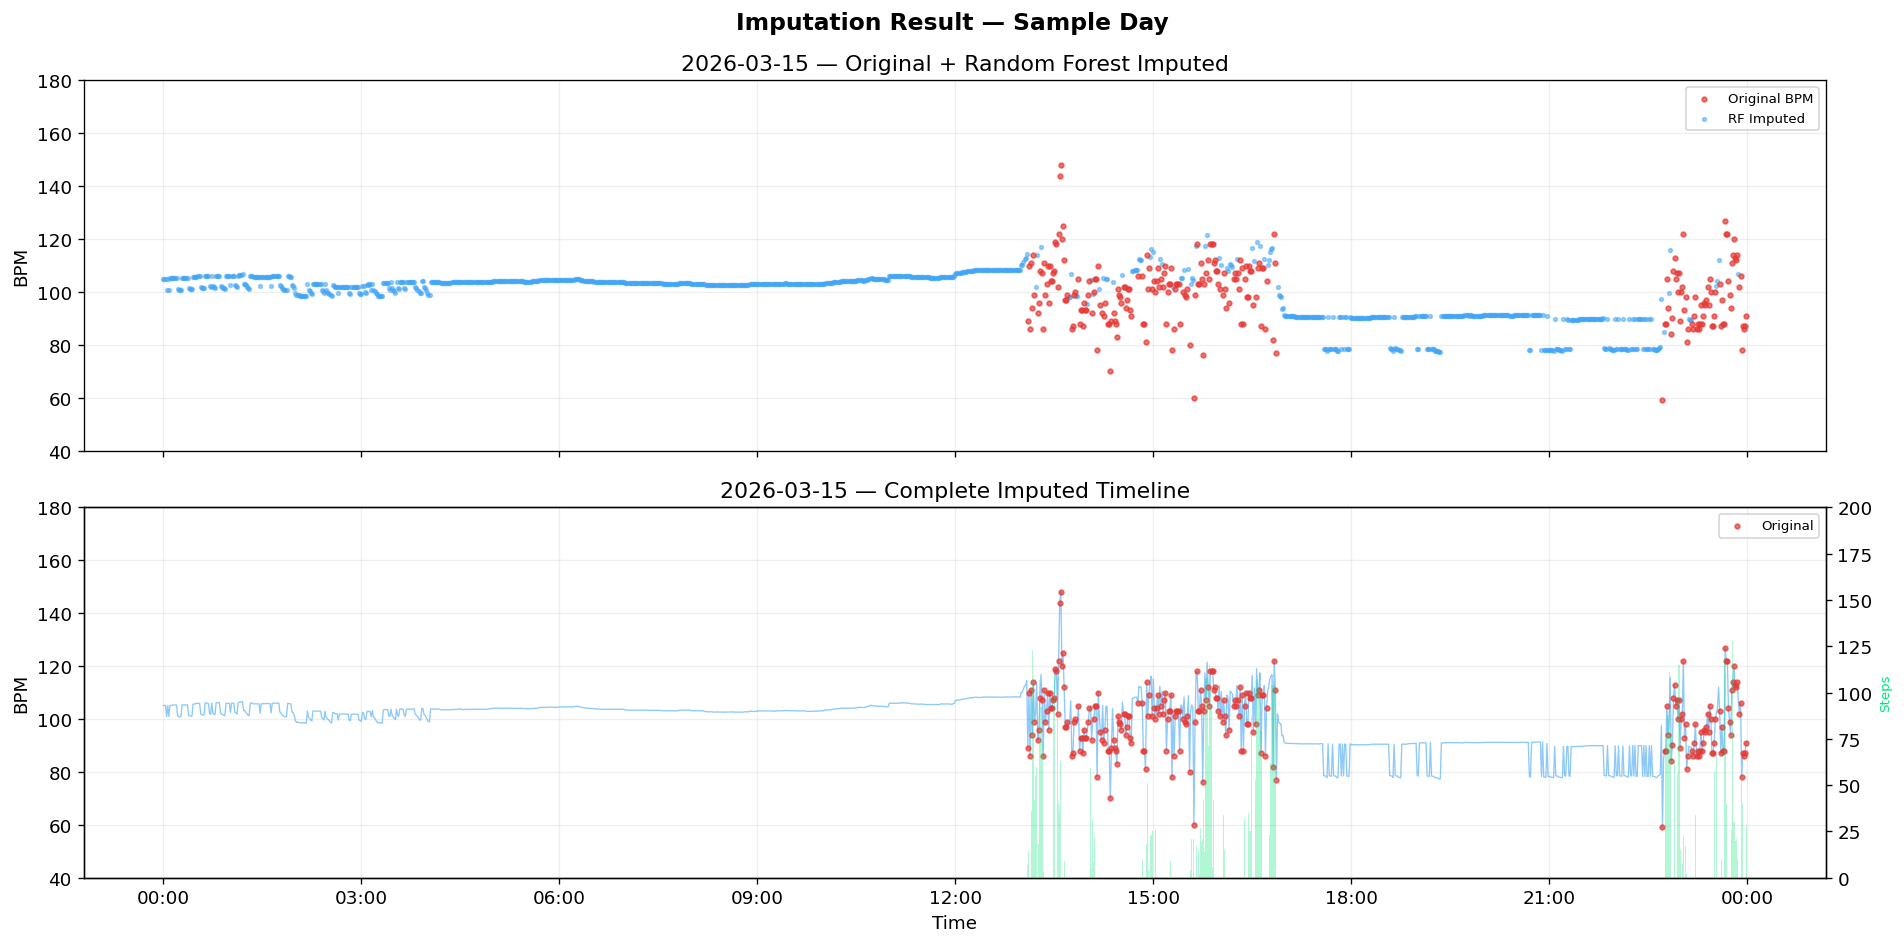

In [11]:
# Impute missing BPM using both models
missing_mask = timeline['bpm'].isna()
X_missing = timeline.loc[missing_mask, feature_cols].values
valid_missing = ~np.any(np.isnan(X_missing), axis=1)

print(f'Missing BPM minutes: {missing_mask.sum():,}')
print(f'  With valid features (can impute): {valid_missing.sum():,}')
print(f'  Without valid features (edges):   {(~valid_missing).sum():,}')

X_missing_clean = X_missing[valid_missing]
rf_imputed = rf.predict(X_missing_clean)
lr_imputed = lr.predict(X_missing_clean)

# Clip to physiological range
rf_imputed = np.clip(rf_imputed, 40, 200)
lr_imputed = np.clip(lr_imputed, 40, 200)

print(f'\nImputed BPM statistics (Random Forest):')
print(f'  Mean: {rf_imputed.mean():.1f}, Std: {rf_imputed.std():.1f}')
print(f'  Range: [{rf_imputed.min():.0f}, {rf_imputed.max():.0f}]')

print(f'\nImputed BPM statistics (Linear Regression):')
print(f'  Mean: {lr_imputed.mean():.1f}, Std: {lr_imputed.std():.1f}')
print(f'  Range: [{lr_imputed.min():.0f}, {lr_imputed.max():.0f}]')

# Add to timeline
timeline['bpm_rf'] = timeline['bpm'].copy()
timeline['bpm_lr'] = timeline['bpm'].copy()
valid_missing_idx = timeline.index[missing_mask][valid_missing]
timeline.loc[valid_missing_idx, 'bpm_rf'] = rf_imputed
timeline.loc[valid_missing_idx, 'bpm_lr'] = lr_imputed

# --- Visualize imputed timeline for a sample day ---
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle('Imputation Result — Sample Day', fontsize=14, fontweight='bold')

# Pick a day with both known and missing data
daily_mix = timeline.groupby('day').agg(
    known=('bpm', lambda x: x.notna().sum()),
    missing=('bpm', lambda x: x.isna().sum())
)
# Day with decent mix of known and missing
good_days = daily_mix[(daily_mix['known'] > 200) & (daily_mix['missing'] > 200)]
if len(good_days) > 0:
    show_day = good_days.index[len(good_days)//2]
else:
    show_day = daily_mix.index[len(daily_mix)//2]

day_data = timeline[timeline['day'] == show_day]
day_str = str(show_day.date()) if hasattr(show_day, 'date') else str(show_day)

# Plot 1: Original with gaps
ax = axes[0]
known_day = day_data[day_data['bpm'].notna()]
ax.scatter(known_day['minute'], known_day['bpm'], s=8, color='#e53935', alpha=0.7, label='Original BPM', zorder=3)
missing_day = day_data[day_data['bpm'].isna() & day_data['bpm_rf'].notna()]
ax.scatter(missing_day['minute'], missing_day['bpm_rf'], s=5, color='#42a5f5', alpha=0.5, label='RF Imputed', zorder=2)
ax.set_ylabel('BPM')
ax.set_title(f'{day_str} — Original + Random Forest Imputed')
ax.set_ylim(40, 180)
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

# Plot 2: Fully imputed timeline
ax = axes[1]
ax.plot(day_data['minute'], day_data['bpm_rf'], linewidth=0.8, color='#42a5f5', alpha=0.6)
ax.scatter(known_day['minute'], known_day['bpm'], s=8, color='#e53935', alpha=0.7, label='Original', zorder=3)
ax2 = ax.twinx()
ax2.bar(day_data['minute'], day_data['steps'], width=0.0007, color='#00e676', alpha=0.3)
ax2.set_ylabel('Steps', fontsize=8, color='#00e676')
ax2.set_ylim(0, 200)
ax.set_ylabel('BPM')
ax.set_xlabel('Time')
ax.set_title(f'{day_str} — Complete Imputed Timeline')
ax.set_ylim(40, 180)
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.savefig('Charts/imputation_result.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 11: Save Results & Summary Table

In [12]:
# Save enhanced timeline with features and imputed values
timeline.to_csv('Data/timeline_features.csv', index=False)
print(f'Saved: Data/timeline_features.csv ({timeline.shape})')

# Save imputed BPM separately
imputed_out = timeline[['minute', 'bpm', 'bpm_rf', 'bpm_lr']].copy()
imputed_out.to_csv('Data/imputed_bpm.csv', index=False)
print(f'Saved: Data/imputed_bpm.csv')

# --- Summary Table ---
print('\n' + '=' * 60)
print('PHASE 2 RESULTS SUMMARY')
print('=' * 60)

summary = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'CV RMSE': [f'{lr_rmse_scores.mean():.2f} +/- {lr_rmse_scores.std():.2f}',
                f'{rf_rmse_scores.mean():.2f} +/- {rf_rmse_scores.std():.2f}'],
    'CV MAE': [f'{lr_mae_scores.mean():.2f} +/- {lr_mae_scores.std():.2f}',
               f'{rf_mae_scores.mean():.2f} +/- {rf_mae_scores.std():.2f}'],
    'CV R2': [f'{lr_r2_scores.mean():.4f} +/- {lr_r2_scores.std():.4f}',
              f'{rf_r2_scores.mean():.4f} +/- {rf_r2_scores.std():.4f}'],
})
print(summary.to_string(index=False))

print(f'\nFeatures used: {len(feature_cols)}')
print(f'Training samples: {len(X_train):,}')
print(f'Missing samples imputed: {valid_missing.sum():,}')
print(f'\nTop 3 most important features (Random Forest):')
for feat, imp in feat_imp.head(3).items():
    print(f'  {feat}: {imp:.1%}')

print(f'\n--- Next Steps ---')
print(f'  Phase 3: Experiments (data amount, composition, augmentation, PCA)')
print(f'  Phase 4: SAITS deep learning model (optional)')
print(f'  Phase 5: Report writing')

Saved: Data/timeline_features.csv ((36930, 42))
Saved: Data/imputed_bpm.csv

PHASE 2 RESULTS SUMMARY
            Model       CV RMSE        CV MAE             CV R2
Linear Regression 9.56 +/- 0.18 7.11 +/- 0.15 0.7296 +/- 0.0097
    Random Forest 9.33 +/- 0.13 6.97 +/- 0.13 0.7427 +/- 0.0086

Features used: 26
Training samples: 11,821
Missing samples imputed: 24,882

Top 3 most important features (Random Forest):
  bpm_neighbor_interp: 24.5%
  bpm_last_known: 18.9%
  bpm_next_known: 17.1%

--- Next Steps ---
  Phase 3: Experiments (data amount, composition, augmentation, PCA)
  Phase 4: SAITS deep learning model (optional)
  Phase 5: Report writing
